In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction, CatalyticMichaelisMenten

import sys
sys.path.append('../../..')
from apps.habituation.hallmarks_helpers import compute_habituation_time, rectangular_pulse_program, compute_recovery_time

## Parameter Values

In [2]:
CIFF_Parameters = {
    'kIa1': 0.023, 'kIi1': 34.44,
    'kMa1': 17.7071, 'kMi1': 0.038241,
    'kRa1': 57.9236, 'kRi1': 1.39117, 'K1': 0.000534,
    'kIa2': 0.016011, 'kIi2': 14.3342,
    'kMa2': 4.33609, 'kMi2': 0.001471,
    'kRa2': 26.1702, 'kRi2': 45.9986, 'K2': 0.79082,
}

## Build CIFF I/O CRN

In [3]:
p = dict(CIFF_Parameters)

reactions = [
    # First incoherent feed-forward motif.
    MassAction(['I1_i'], ['I1_a'], input_channels=['S'],
               params=[p['kIa1']], params_controllability=[False]),
    MassAction(['I1_a'], ['I1_i'], input_channels=[None],
               params=[p['kIi1']], params_controllability=[False]),
    MassAction(['I1_a', 'M1_i'], ['I1_a', 'M1_a'], input_channels=[None],
               params=[p['kMa1']], params_controllability=[False]),
    MassAction(['M1_a'], ['M1_i'], input_channels=[None],
               params=[p['kMi1']], params_controllability=[False]),
    MassAction(['I1_a', 'R1_i'], ['I1_a', 'R1_a'], input_channels=[None],
               params=[p['kRa1']], params_controllability=[False]),
    CatalyticMichaelisMenten(['R1_a'], ['R1_i'], ['M1_a'],
                              params=[p['kRi1'], p['K1']],
                              params_controllability=[False, False]),

    # Second motif, driven by active R1.
    MassAction(['R1_a', 'I2_i'], ['R1_a', 'I2_a'], input_channels=[None],
               params=[p['kIa2']], params_controllability=[False]),
    MassAction(['I2_a'], ['I2_i'], input_channels=[None],
               params=[p['kIi2']], params_controllability=[False]),
    MassAction(['I2_a', 'M2_i'], ['I2_a', 'M2_a'], input_channels=[None],
               params=[p['kMa2']], params_controllability=[False]),
    MassAction(['M2_a'], ['M2_i'], input_channels=[None],
               params=[p['kMi2']], params_controllability=[False]),
    MassAction(['I2_a', 'R2_i'], ['I2_a', 'R2_a'], input_channels=[None],
               params=[p['kRa2']], params_controllability=[False]),
    CatalyticMichaelisMenten(['R2_a'], ['R2_i'], ['M2_a'],
                              params=[p['kRi2'], p['K2']],
                              params_controllability=[False, False]),
]

ciff = IOCRN(reactions, output_labels=['R2_a'], solver='LSODA', atol=1e-9, rtol=1e-7)
ciff.compile()
print(ciff)

Inputs: ['S'] 
Species: ['I1_a', 'I1_i', 'I2_a', 'I2_i', 'M1_a', 'M1_i', 'M2_a', 'M2_i', 'R1_a', 'R1_i', 'R2_a', 'R2_i'] 
Output Species: ['R2_a'] 
I1_i ----> I1_a;  [MAK(0.023, S)]
I1_a ----> I1_i;  [MAK(34.44)]
I1_a + M1_i ----> I1_a + M1_a;  [MAK(17.7071)]
M1_a ----> M1_i;  [MAK(0.038241)]
I1_a + R1_i ----> I1_a + R1_a;  [MAK(57.9236)]
R1_a ----> R1_i;  [CatalyticMM(E=M1_a, k=1.39117, K=0.000534)]
I2_i + R1_a ----> I2_a + R1_a;  [MAK(0.016011)]
I2_a ----> I2_i;  [MAK(14.3342)]
I2_a + M2_i ----> I2_a + M2_a;  [MAK(4.33609)]
M2_a ----> M2_i;  [MAK(0.001471)]
I2_a + R2_i ----> I2_a + R2_a;  [MAK(26.1702)]
R2_a ----> R2_i;  [CatalyticMM(E=M2_a, k=45.9986, K=0.79082)]


## Initial Conditions

In [4]:
def inactive_initial_condition(crn):
    x0 = np.zeros(crn.num_species)
    for label in ['I1_i', 'M1_i', 'R1_i', 'I2_i', 'M2_i', 'R2_i']:
        x0[crn.species_label_to_idx(label)] = 1.0
    return x0

x0 = inactive_initial_condition(ciff)
print(x0)

[0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.]


## Simulate

In [5]:
A, T, Ton, n_pulses = 10.0, 20, 1.1111111111111112, 50  # A and T may also be lists
u_program, time_segments = rectangular_pulse_program(A, T, Ton, n_pulses)
time, trajectories, outputs, _ = ciff.transient_response_piecewise(
    u_nested_list=u_program,
    x0_list=[x0],
    nested_time_horizon=time_segments,
    force=True,
)

## Calculate Habituation Time and Plot Trajectory

Habituation time: 22 pulses


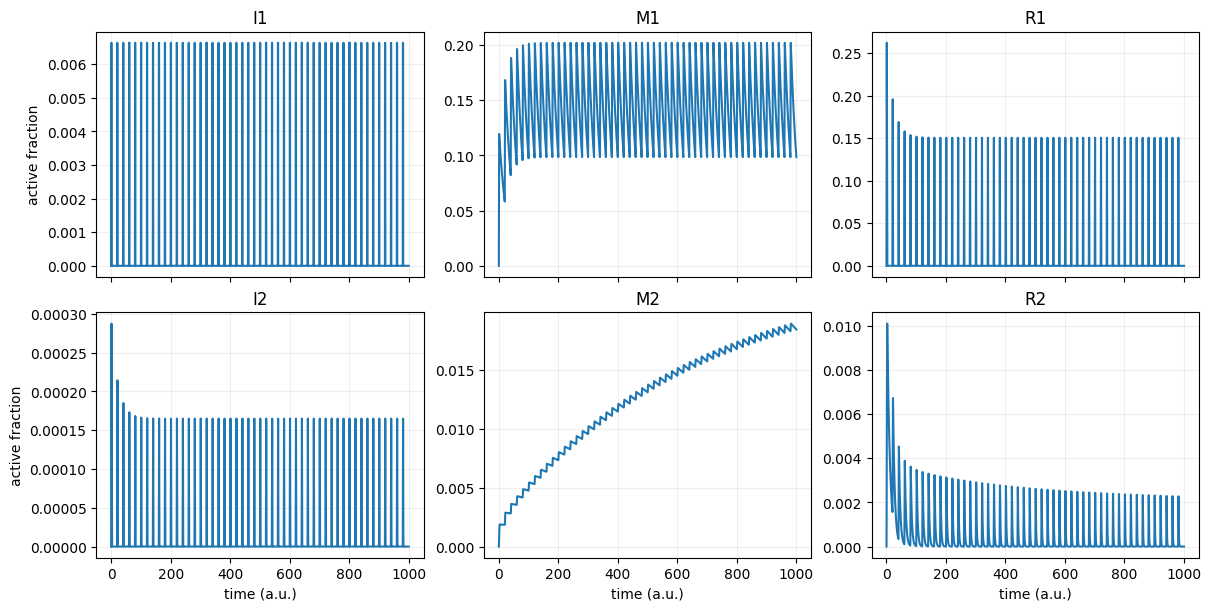

In [6]:
habituation_time, response_peaks = compute_habituation_time(time, outputs[0][0], T, n_pulses, tolerance=0.01)
print(f'Habituation time: {habituation_time} pulses')

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, constrained_layout=True)
species_grid = [['I1_a', 'M1_a', 'R1_a'], ['I2_a', 'M2_a', 'R2_a']]

for row_idx, row in enumerate(species_grid):
    for col_idx, species in enumerate(row):
        ax = axes[row_idx, col_idx]
        ax.plot(time, trajectories[0][ciff.species_label_to_idx(species)], linewidth=1.5)
        ax.set_title(species.replace('_a', ''))
        ax.grid(alpha=0.2)
        if col_idx == 0:
            ax.set_ylabel('active fraction')
        if row_idx == 1:
            ax.set_xlabel('time (a.u.)')

plt.show()

## Calculate Recovery Time

In [7]:
recovery_time, recovery_difference, recovery_peak = compute_recovery_time(ciff, A, T, Ton, habituation_time, x0)
print(f'Recovery time: {recovery_time} a.u. (difference from first pulse response: {recovery_difference:.4f}, recovery peak: {recovery_peak:.4f})')

Recovery time: 1914.12353515625 a.u. (difference from first pulse response: 0.0500, recovery peak: 0.0096)
